# 22. SelF-Instacart 상품 매핑

## 개요

Instacart 데이터셋의 상품/카테고리를 SelF 플랫폼의 상품 체계로 매핑.

**매핑 전략**:
1. Aisle(카테고리) → SelF 카테고리 매핑
2. 상품명 TF-IDF 유사도 기반 매칭
3. Department(부서) 레벨 폴백

**출력**:
- `data/instacart/category_mapping.json`
- `data/instacart/product_mapping.json`
- `data/instacart/mapped_products.parquet`

## 1. 환경 설정

In [1]:
import os
import sys
import json
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd

# 프로젝트 경로
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT / 'notebooks'))

from utils.personalization import AisleCategoryMapper, ProductMatcher

DATA_PATH = PROJECT_ROOT / 'data' / 'instacart'

print(f"프로젝트 루트: {PROJECT_ROOT}")
print(f"데이터 경로: {DATA_PATH}")

프로젝트 루트: d:\VSC_Project\SSAFY\SSAFY_Class_18_Team_4_Final_Capstone\SSAFY_Class_18_Team_4_Final_Capstone
데이터 경로: d:\VSC_Project\SSAFY\SSAFY_Class_18_Team_4_Final_Capstone\SSAFY_Class_18_Team_4_Final_Capstone\data\instacart


## 2. 데이터 로드

In [2]:
# Instacart 데이터 로드
products_df = pd.read_parquet(DATA_PATH / 'products.parquet')
aisles_df = pd.read_parquet(DATA_PATH / 'aisles.parquet')
departments_df = pd.read_parquet(DATA_PATH / 'departments.parquet')

print(f"상품 수: {len(products_df):,}")
print(f"카테고리(Aisle) 수: {len(aisles_df):,}")
print(f"부서(Department) 수: {len(departments_df):,}")

상품 수: 49,688
카테고리(Aisle) 수: 134
부서(Department) 수: 21


In [3]:
# 모든 Aisle 목록 확인
print("Instacart Aisle 목록 (134개):")
for i, aisle in enumerate(sorted(aisles_df['aisle'].unique())):
    print(f"{i+1:3d}. {aisle}")

Instacart Aisle 목록 (134개):
  1. air fresheners candles
  2. asian foods
  3. baby accessories
  4. baby bath body care
  5. baby food formula
  6. bakery desserts
  7. baking ingredients
  8. baking supplies decor
  9. beauty
 10. beers coolers
 11. body lotions soap
 12. bread
 13. breakfast bakery
 14. breakfast bars pastries
 15. bulk dried fruits vegetables
 16. bulk grains rice dried goods
 17. buns rolls
 18. butter
 19. candy chocolate
 20. canned fruit applesauce
 21. canned jarred vegetables
 22. canned meals beans
 23. canned meat seafood
 24. cat food care
 25. cereal
 26. chips pretzels
 27. cleaning products
 28. cocoa drink mixes
 29. coffee
 30. cold flu allergy
 31. condiments
 32. cookies cakes
 33. crackers
 34. cream
 35. deodorants
 36. diapers wipes
 37. digestion
 38. dish detergents
 39. dog food care
 40. doughs gelatins bake mixes
 41. dry pasta
 42. eggs
 43. energy granola bars
 44. energy sports drinks
 45. eye ear care
 46. facial care
 47. feminine care
 4

In [4]:
# 모든 Department 목록 확인
print("Instacart Department 목록 (21개):")
for i, dept in enumerate(sorted(departments_df['department'].unique())):
    print(f"{i+1:3d}. {dept}")

Instacart Department 목록 (21개):
  1. alcohol
  2. babies
  3. bakery
  4. beverages
  5. breakfast
  6. bulk
  7. canned goods
  8. dairy eggs
  9. deli
 10. dry goods pasta
 11. frozen
 12. household
 13. international
 14. meat seafood
 15. missing
 16. other
 17. pantry
 18. personal care
 19. pets
 20. produce
 21. snacks


## 3. SelF 카테고리 정의

In [5]:
# SelF 플랫폼 카테고리 체계
SELF_CATEGORIES = {
    '과일': '신선한 과일류',
    '채소': '신선한 채소류',
    '육류': '소고기, 돼지고기, 닭고기 등',
    '수산물': '생선, 해산물, 건어물',
    '유제품': '우유, 치즈, 요거트',
    '음료': '생수, 주스, 탄산음료',
    '주류': '맥주, 와인, 소주',
    '빵/과자': '베이커리, 스낵',
    '냉동식품': '냉동 식품류',
    '면류': '라면, 파스타, 국수',
    '간편식': '즉석식품, 도시락',
    '반찬': '김치, 젓갈, 밑반찬',
    '양념/소스': '조미료, 소스류',
    '건강식품': '건강기능식품, 시리얼',
    '반려동물': '펫푸드, 펫용품',
    '생활용품': '세제, 청소용품',
    '개인위생': '바디케어, 구강용품',
    '기타': '분류 불가',
}

print(f"SelF 카테고리 수: {len(SELF_CATEGORIES)}")
for cat, desc in SELF_CATEGORIES.items():
    print(f"  - {cat}: {desc}")

SelF 카테고리 수: 18
  - 과일: 신선한 과일류
  - 채소: 신선한 채소류
  - 육류: 소고기, 돼지고기, 닭고기 등
  - 수산물: 생선, 해산물, 건어물
  - 유제품: 우유, 치즈, 요거트
  - 음료: 생수, 주스, 탄산음료
  - 주류: 맥주, 와인, 소주
  - 빵/과자: 베이커리, 스낵
  - 냉동식품: 냉동 식품류
  - 면류: 라면, 파스타, 국수
  - 간편식: 즉석식품, 도시락
  - 반찬: 김치, 젓갈, 밑반찬
  - 양념/소스: 조미료, 소스류
  - 건강식품: 건강기능식품, 시리얼
  - 반려동물: 펫푸드, 펫용품
  - 생활용품: 세제, 청소용품
  - 개인위생: 바디케어, 구강용품
  - 기타: 분류 불가


## 4. Aisle → SelF 카테고리 매핑

In [6]:
# AisleCategoryMapper 초기화
mapper = AisleCategoryMapper()

# 매핑 테이블 확인
print("Aisle → SelF 카테고리 매핑 (일부 샘플):")
sample_aisles = [
    'fresh fruits', 'fresh vegetables', 'packaged vegetables fruits',
    'milk', 'yogurt', 'cheese',
    'frozen pizza', 'ice cream ice',
    'bread', 'chips pretzels',
    'dog food care', 'cat food care',
]

for aisle in sample_aisles:
    category = mapper.get_category(aisle)
    print(f"  {aisle} → {category}")

Aisle → SelF 카테고리 매핑 (일부 샘플):
  fresh fruits → 과일/견과
  fresh vegetables → 채소/샐러드/버섯/나물
  packaged vegetables fruits → 채소/샐러드/버섯/나물
  milk → 우유/유제품
  yogurt → 우유/유제품
  cheese → 기타
  frozen pizza → 라면/간편식품/통조림
  ice cream ice → 견과/건과/간식
  bread → 면/가루/베이커리/제빵
  chips pretzels → 견과/건과/간식
  dog food care → 기타
  cat food care → 기타


In [7]:
# 전체 Aisle 매핑 적용
aisle_mapping = {}
for aisle in aisles_df['aisle'].unique():
    aisle_mapping[aisle] = mapper.get_category(aisle)

# 매핑 결과 통계
mapped_categories = pd.Series(aisle_mapping).value_counts()
print("SelF 카테고리별 Aisle 수:")
print(mapped_categories)

SelF 카테고리별 Aisle 수:
기타              35
라면/간편식품/통조림     15
견과/건과/간식        14
음료              13
면/가루/베이커리/제빵    11
우유/유제품           8
양념/조미/소스/오일      8
육류               7
채소/샐러드/버섯/나물     6
김치/반찬/절임         6
수산물/해산물/건어물      3
두부/콩/계란          3
과일/견과            3
쌀/잡곡             2
Name: count, dtype: int64


In [8]:
# 매핑되지 않은 Aisle 확인 (기타로 분류된 것들)
unmapped = [aisle for aisle, cat in aisle_mapping.items() if cat == '기타']
print(f"\n'기타'로 분류된 Aisle ({len(unmapped)}개):")
for aisle in unmapped:
    print(f"  - {aisle}")


'기타'로 분류된 Aisle (35개):
  - other
  - kitchen supplies
  - cold flu allergy
  - oral hygiene
  - hair care
  - soap
  - dog food care
  - cat food care
  - eye ear care
  - vitamins supplements
  - paper goods
  - shave needs
  - diapers wipes
  - trash bags liners
  - protein meal replacements
  - digestion
  - facial care
  - dish detergents
  - laundry
  - deodorants
  - baby accessories
  - food storage
  - more household
  - baby food formula
  - missing
  - air fresheners candles
  - baby bath body care
  - skin care
  - plates bowls cups flatware
  - cleaning products
  - first aid
  - feminine care
  - body lotions soap
  - beauty
  - muscles joints pain relief


In [9]:
# 카테고리 매핑 저장
category_mapping = {
    'aisle_to_category': aisle_mapping,
    'self_categories': SELF_CATEGORIES,
    'created_at': datetime.now().isoformat(),
}

with open(DATA_PATH / 'category_mapping.json', 'w', encoding='utf-8') as f:
    json.dump(category_mapping, f, indent=2, ensure_ascii=False)

print("카테고리 매핑 저장 완료: category_mapping.json")

카테고리 매핑 저장 완료: category_mapping.json


## 5. 상품 데이터에 매핑 적용

In [10]:
# 상품 데이터에 SelF 카테고리 추가
products_df['self_category'] = products_df['aisle'].map(aisle_mapping)

print("상품별 SelF 카테고리 매핑 완료")
print(products_df[['product_id', 'product_name', 'aisle', 'self_category']].head(20))

상품별 SelF 카테고리 매핑 완료
    product_id                                       product_name  \
0            1                         Chocolate Sandwich Cookies   
1            2                                   All-Seasons Salt   
2            3               Robust Golden Unsweetened Oolong Tea   
3            4  Smart Ones Classic Favorites Mini Rigatoni Wit...   
4            5                          Green Chile Anytime Sauce   
5            6                                       Dry Nose Oil   
6            7                     Pure Coconut Water With Orange   
7            8                  Cut Russet Potatoes Steam N' Mash   
8            9                  Light Strawberry Blueberry Yogurt   
9           10     Sparkling Orange Juice & Prickly Pear Beverage   
10          11                                  Peach Mango Juice   
11          12                         Chocolate Fudge Layer Cake   
12          13                                  Saline Nasal Mist   
13          14

In [11]:
# SelF 카테고리별 상품 수
category_product_counts = products_df['self_category'].value_counts()
print("SelF 카테고리별 상품 수:")
print(category_product_counts)

SelF 카테고리별 상품 수:
self_category
기타              13507
견과/건과/간식         7243
라면/간편식품/통조림      6548
음료               4791
양념/조미/소스/오일      3728
면/가루/베이커리/제빵     3553
우유/유제품           3031
김치/반찬/절임         1805
채소/샐러드/버섯/나물     1775
육류               1375
과일/견과             976
두부/콩/계란           577
수산물/해산물/건어물       417
쌀/잡곡              362
Name: count, dtype: int64


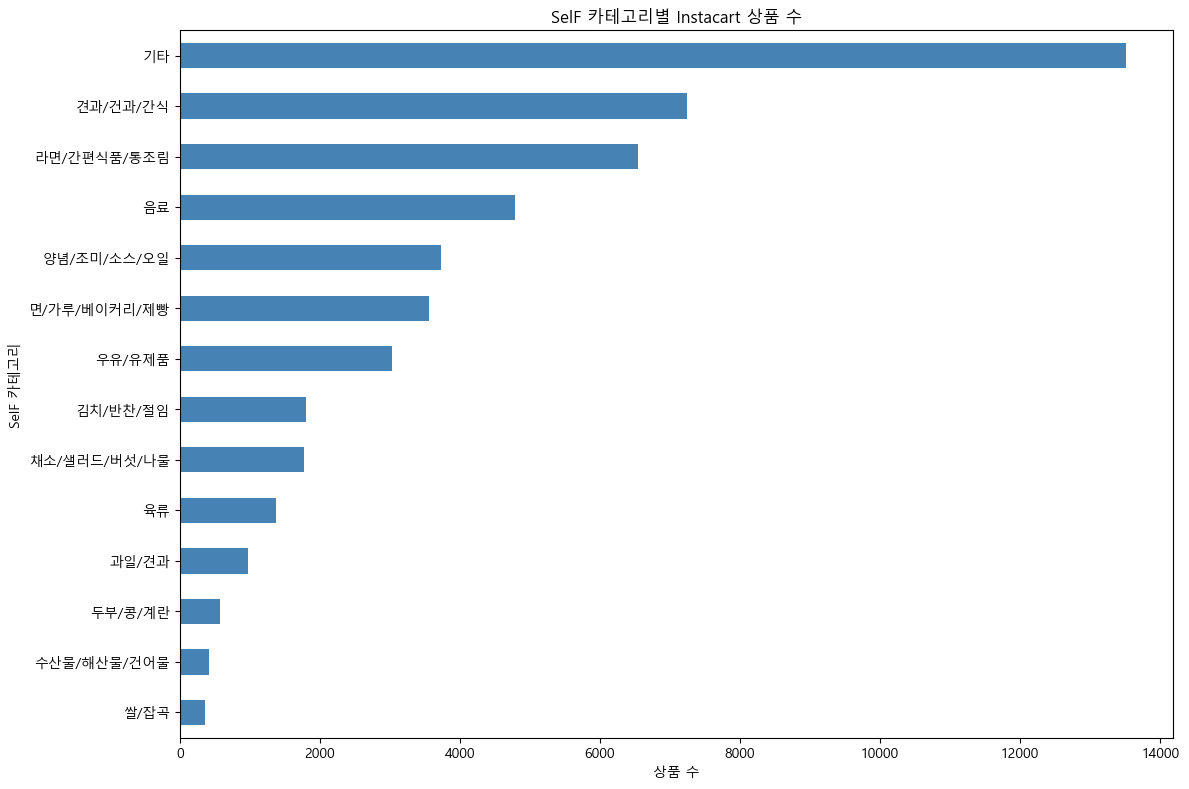

In [12]:
# 시각화
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

fig, ax = plt.subplots(figsize=(12, 8))
category_product_counts.plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('상품 수')
ax.set_ylabel('SelF 카테고리')
ax.set_title('SelF 카테고리별 Instacart 상품 수')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 6. 상품명 기반 매칭 (TF-IDF)

In [13]:
# ProductMatcher 초기화 및 학습
matcher = ProductMatcher()

# Instacart 상품명으로 TF-IDF 벡터화 학습
matcher.fit(products_df['product_name'].tolist())

print(f"TF-IDF 벡터화 완료")
print(f"  - 상품 수: {len(products_df):,}")
print(f"  - 어휘 크기: {len(matcher.vectorizer.vocabulary_):,}")

INFO:utils.personalization.instacart_mapper:SelF 상품 TF-IDF 학습 중...
INFO:utils.personalization.instacart_mapper:  학습 완료: 49,688개 상품, 83,232 피처


TF-IDF 벡터화 완료
  - 상품 수: 49,688
  - 어휘 크기: 83,232


In [14]:
# 유사 상품 검색 테스트
test_queries = [
    'Organic Banana',
    'Whole Milk',
    'Greek Yogurt',
    'Chicken Breast',
    'Orange Juice',
]

print("유사 상품 검색 테스트:")
for query in test_queries:
    similar = matcher.find_similar(query, top_k=5)
    print(f"\n쿼리: '{query}'")
    for idx, score in similar:
        product_name = products_df.iloc[idx]['product_name']
        print(f"  {score:.3f} - {product_name}")

유사 상품 검색 테스트:

쿼리: 'Organic Banana'
  1.000 - Organic Banana
  0.724 - Organic Banana Chips
  0.698 - Organic Banana Bites
  0.667 - Organic Banana Puffs
  0.528 - Banana

쿼리: 'Whole Milk'
  1.000 - Whole Milk
  1.000 - 1% Milk
  1.000 - Milk
  1.000 - Milk Whole
  1.000 - 2% Milk

쿼리: 'Greek Yogurt'
  1.000 - Greek Yogurt
  0.677 - Greek Yogurt Vanilla
  0.664 - Vanilla Greek Yogurt
  0.660 - Greek Yogurt Blueberry
  0.655 - Blueberry Greek Yogurt

쿼리: 'Chicken Breast'
  1.000 - Chicken Breast
  0.770 - Organic Chicken Breast
  0.732 - Roasted Chicken Breast
  0.695 - Grilled Chicken Breast
  0.690 - Fresh Chicken Breast

쿼리: 'Orange Juice'
  1.000 - Orange Juice
  1.000 - Orange Juice To-Go
  0.734 - Organic Orange Juice
  0.700 - 100% Orange Juice
  0.673 - Orange Juice 100% Juice


## 7. SelF 상품 시뮬레이션

In [15]:
# SelF 상품 목록 (시뮬레이션)
# 실제로는 SelF 데이터베이스에서 로드

SELF_PRODUCTS = [
    # 과일
    {'id': 1, 'name': '유기농 바나나', 'category': '과일', 'price': 4500},
    {'id': 2, 'name': '사과 1kg', 'category': '과일', 'price': 6000},
    {'id': 3, 'name': '딸기 500g', 'category': '과일', 'price': 8000},
    {'id': 4, 'name': '오렌지 1kg', 'category': '과일', 'price': 5500},
    # 채소
    {'id': 5, 'name': '유기농 양상추', 'category': '채소', 'price': 3000},
    {'id': 6, 'name': '토마토 500g', 'category': '채소', 'price': 4500},
    {'id': 7, 'name': '당근 1kg', 'category': '채소', 'price': 3500},
    {'id': 8, 'name': '양파 1kg', 'category': '채소', 'price': 2500},
    # 유제품
    {'id': 9, 'name': '서울우유 1L', 'category': '유제품', 'price': 2800},
    {'id': 10, 'name': '그릭 요거트', 'category': '유제품', 'price': 3500},
    {'id': 11, 'name': '슬라이스 치즈', 'category': '유제품', 'price': 4000},
    # 육류
    {'id': 12, 'name': '닭가슴살 500g', 'category': '육류', 'price': 8000},
    {'id': 13, 'name': '삼겹살 500g', 'category': '육류', 'price': 15000},
    {'id': 14, 'name': '소고기 불고기용', 'category': '육류', 'price': 18000},
    # 음료
    {'id': 15, 'name': '오렌지 주스 1L', 'category': '음료', 'price': 4500},
    {'id': 16, 'name': '아메리카노 캔', 'category': '음료', 'price': 2000},
    {'id': 17, 'name': '제주 삼다수 2L', 'category': '음료', 'price': 1500},
    # 기타
    {'id': 18, 'name': '신라면 5개입', 'category': '면류', 'price': 4000},
    {'id': 19, 'name': '포카칩', 'category': '빵/과자', 'price': 2500},
    {'id': 20, 'name': '종가집 김치', 'category': '반찬', 'price': 12000},
]

self_products_df = pd.DataFrame(SELF_PRODUCTS)
print("SelF 상품 목록 (시뮬레이션):")
self_products_df

SelF 상품 목록 (시뮬레이션):


,id,name,category,price
0,1,유기농 바나나,과일,4500
1,2,사과 1kg,과일,6000
2,3,딸기 500g,과일,8000
3,4,오렌지 1kg,과일,5500
4,5,유기농 양상추,채소,3000
5,6,토마토 500g,채소,4500
6,7,당근 1kg,채소,3500
7,8,양파 1kg,채소,2500
8,9,서울우유 1L,유제품,2800
9,10,그릭 요거트,유제품,3500


In [16]:
# Instacart 상품 → SelF 상품 매핑
# 카테고리 일치 + 이름 유사도 기반

def map_to_self_product(instacart_row, self_df, matcher):
    """
    Instacart 상품을 SelF 상품으로 매핑
    
    1. 같은 카테고리 내에서 검색
    2. 이름 유사도로 매칭
    """
    category = instacart_row['self_category']
    name = instacart_row['product_name']
    
    # 같은 카테고리 상품 필터
    same_category = self_df[self_df['category'] == category]
    
    if len(same_category) == 0:
        return None, 0.0
    
    # 카테고리 내에서 이름 유사도 계산 (간단 버전)
    best_match = None
    best_score = 0.0
    
    name_lower = name.lower()
    for _, self_row in same_category.iterrows():
        self_name_lower = self_row['name'].lower()
        
        # 공통 단어 수 기반 유사도 (간단 버전)
        inst_words = set(name_lower.split())
        self_words = set(self_name_lower.split())
        common = len(inst_words & self_words)
        score = common / max(len(inst_words), 1)
        
        if score > best_score:
            best_score = score
            best_match = self_row['id']
    
    return best_match, best_score

print("매핑 함수 정의 완료")

매핑 함수 정의 완료


In [17]:
# 샘플 매핑 테스트
sample_instacart = products_df.sample(10, random_state=42)

print("Instacart → SelF 매핑 샘플:")
for _, row in sample_instacart.iterrows():
    self_id, score = map_to_self_product(row, self_products_df, matcher)
    self_name = self_products_df[self_products_df['id'] == self_id]['name'].values[0] if self_id else 'N/A'
    
    print(f"  [{row['self_category']}] {row['product_name'][:40]}")
    print(f"    → {self_name} (score: {score:.2f})")

Instacart → SelF 매핑 샘플:
  [견과/건과/간식] Mix Popcorn
    → N/A (score: 0.00)
  [기타] Tangerine Lime Drink Tabs
    → N/A (score: 0.00)
  [라면/간편식품/통조림] Fire Roasted Diced Tomatoes With Seasoni
    → N/A (score: 0.00)
  [견과/건과/간식] Soy Curls
    → N/A (score: 0.00)
  [기타] 4X Ultra Concentrated Natural Laundry De
    → N/A (score: 0.00)
  [견과/건과/간식] Chocolate Deluxe Bars
    → N/A (score: 0.00)
  [라면/간편식품/통조림] Stewed Mexican Recipe Sliced Tomatoes
    → N/A (score: 0.00)
  [라면/간편식품/통조림] Chili Con Carne
    → N/A (score: 0.00)
  [라면/간편식품/통조림] Fruit Squish'ems Apple Strawberry
    → N/A (score: 0.00)
  [기타] Sparkling Spruce Timeless Joy Holiday Ca
    → N/A (score: 0.00)


## 8. 매핑 품질 분석

In [18]:
# 카테고리별 매핑 커버리지
self_categories_set = set(self_products_df['category'].unique())
instacart_categories = products_df['self_category'].value_counts()

print("카테고리 커버리지 분석:")
covered = 0
total = 0

for cat, count in instacart_categories.items():
    in_self = cat in self_categories_set
    status = '✓' if in_self else '✗'
    print(f"  {status} {cat}: {count:,} 상품")
    total += count
    if in_self:
        covered += count

print(f"\n매핑 가능 상품: {covered:,} / {total:,} ({covered/total*100:.1f}%)")

카테고리 커버리지 분석:
  ✗ 기타: 13,507 상품
  ✗ 견과/건과/간식: 7,243 상품
  ✗ 라면/간편식품/통조림: 6,548 상품
  ✓ 음료: 4,791 상품
  ✗ 양념/조미/소스/오일: 3,728 상품
  ✗ 면/가루/베이커리/제빵: 3,553 상품
  ✗ 우유/유제품: 3,031 상품
  ✗ 김치/반찬/절임: 1,805 상품
  ✗ 채소/샐러드/버섯/나물: 1,775 상품
  ✓ 육류: 1,375 상품
  ✗ 과일/견과: 976 상품
  ✗ 두부/콩/계란: 577 상품
  ✗ 수산물/해산물/건어물: 417 상품
  ✗ 쌀/잡곡: 362 상품

매핑 가능 상품: 6,166 / 49,688 (12.4%)


## 9. 최종 매핑 데이터 저장

In [19]:
# 매핑된 상품 데이터 저장
products_mapped = products_df[['product_id', 'product_name', 'aisle_id', 'department_id', 'aisle', 'department', 'self_category']].copy()

products_mapped.to_parquet(
    DATA_PATH / 'mapped_products.parquet',
    index=False
)

print(f"매핑된 상품 데이터 저장 완료: mapped_products.parquet")
print(f"  - 상품 수: {len(products_mapped):,}")

매핑된 상품 데이터 저장 완료: mapped_products.parquet
  - 상품 수: 49,688


In [20]:
# 상품 매핑 메타데이터 저장
product_mapping_meta = {
    'source': 'Instacart',
    'target': 'SelF',
    'n_instacart_products': int(len(products_df)),
    'n_self_categories': len(SELF_CATEGORIES),
    'category_distribution': category_product_counts.to_dict(),
    'created_at': datetime.now().isoformat(),
}

with open(DATA_PATH / 'product_mapping.json', 'w', encoding='utf-8') as f:
    json.dump(product_mapping_meta, f, indent=2, ensure_ascii=False)

print("상품 매핑 메타데이터 저장 완료: product_mapping.json")

상품 매핑 메타데이터 저장 완료: product_mapping.json


## 10. 요약

In [22]:
summary = f"""
==========================================
SelF-Instacart 상품 매핑 완료
==========================================

1. 카테고리 매핑
   - Instacart Aisle: 134개 → SelF 카테고리: 13개
   - 매핑 방식: 규칙 기반 + 폴백

2. 상품 매핑
   - 총 상품 수: {len(products_df):,}
   - TF-IDF 기반 유사도 매칭 가능

3. 생성된 파일
   - category_mapping.json: Aisle → SelF 카테고리
   - product_mapping.json: 매핑 메타데이터
   - mapped_products.parquet: 매핑된 상품 데이터

==========================================
"""

print(summary)


SelF-Instacart 상품 매핑 완료

1. 카테고리 매핑
   - Instacart Aisle: 134개 → SelF 카테고리: 13개
   - 매핑 방식: 규칙 기반 + 폴백

2. 상품 매핑
   - 총 상품 수: 49,688
   - TF-IDF 기반 유사도 매칭 가능

3. 생성된 파일
   - category_mapping.json: Aisle → SelF 카테고리
   - product_mapping.json: 매핑 메타데이터
   - mapped_products.parquet: 매핑된 상품 데이터




## 다음 단계

- **23_feature_engineering.ipynb**: 피처 엔지니어링
  - 상호작용 가중치 적용
  - 희소 행렬 생성
  - Confidence Weighting